# Urgency Tagging with GRU Model

Notebook ini mengimplementasikan model Recurrent Neural Network (RNN) berbasis **Gated Recurrent Unit (GRU)** untuk melakukan klasifikasi tingkat urgensi komplain konsumen (High, Medium, Low).

Pipeline yang diimplementasikan meliputi:
1. Memuat dataset ter-lemmatisasi (`cleaned_complaints.csv`)
2. Pembagian data stratified (Train, Validation, Test)
3. Label encoding kelas target
4. Tokenisasi teks & padding sekuens teks
5. Penanganan kelas imbalanced menggunakan class weight
6. Definisi arsitektur model GRU (Embedding, Bidirectional GRU, Dense, Softmax)
7. Pelatihan model dengan Early Stopping & Checkpointing
8. Visualisasi performa model (Loss & Accuracy curves)
9. Evaluasi model (Classification Report & Confusion Matrix)

In [9]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Deteksi apakah berjalan di Google Colab atau lokal
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Jalur absolut menuju direktori root proyek di Drive
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    # Berjalan secara lokal (VS Code / Jupyter Notebook)
    notebook_dir = os.getcwd()
    if os.path.basename(notebook_dir) == 'notebooks':
        PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..'))
    else:
        PROJECT_ROOT = notebook_dir
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

# Tambahkan root proyek ke sys.path jika belum terdaftar
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import pipeline standard dari src.features (setelah sys.path diatur)
from src.features import split_data, extract_lstm_sequences

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Styling untuk visualisasi
sns.set_theme(style='whitegrid')
print("Semua library berhasil diimport.")

Berjalan secara lokal. Project root: d:\Projek\lentera-analytics-hub\lentera-ml-research
Semua library berhasil diimport.


## 1. Load dan Validasi Dataset Bersih
Kita akan memuat dataset hasil pembersihan dan normalisasi teks yang telah disimpan di `data/processed/cleaned_complaints.csv`.

In [10]:
# Membaca dataset yang telah melalui proses pembersihan teks
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

# Validasi: hapus baris dengan nilai kosong pada kolom kunci
df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

# Cek distribusi kelas
print("Distribusi kelas Urgency:")
print(df['Urgency'].value_counts())

Dataset berhasil dimuat. Shape awal: (53927, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (53927, 3)

Distribusi kelas Urgency:
Urgency
Medium    20952
High      20771
Low       12204
Name: count, dtype: int64


## 2. Pembagian Data (Data Splitting)
Kita membagi dataset secara stratified menjadi Train (70%), Validation (15%), dan Test (15%) dengan menggunakan fungsi `split_data` yang sudah tersedia di `src.features`.

In [11]:
# Memanggil fungsi split_data dari src.features
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

Train size: 37748, Val size: 8089, Test size: 8090


## 3. Label Encoding Target
Model deep learning membutuhkan target numerik. Kita akan mengodekan target kategori `'High'`, `'Medium'`, dan `'Low'` menggunakan `LabelEncoder` dari scikit-learn.

In [12]:
# Label encoding target 'Urgency' menjadi integer
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(df_train['Urgency'])
y_val_encoded = label_encoder.transform(df_val['Urgency'])
y_test_encoded = label_encoder.transform(df_test['Urgency'])

# Tampilkan pemetaan kelas
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Pemetaan kelas target:", class_mapping)

Pemetaan kelas target: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 4. Tokenisasi dan Padding Sekuens
Kita mengubah teks komplain menjadi representasi sekuens integer menggunakan `extract_lstm_sequences` dari `src.features`. Ukuran kosakata dibatasi maksimal 10.000 kata dan panjang sekuens maksimal dipotong/diisi hingga 150 token.

In [13]:
# Ekstraksi tokenisasi sekuens teks
X_train_pad, X_val_pad, X_test_pad, tokenizer = extract_lstm_sequences(
    df_train['Cleaned_Narrative'],
    df_val['Cleaned_Narrative'],
    df_test['Cleaned_Narrative'],
    max_words=10000,
    max_len=150
)

print(f"Shape data sekuens:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")

Shape data sekuens:
  X_train_pad : (37748, 150)
  X_val_pad   : (8089, 150)
  X_test_pad  : (8090, 150)


## 5. Penanganan Kelas Imbalanced
Karena sebaran kelas target tidak merata, kita menghitung *class weight* untuk menaikkan bobot kelas minoritas selama pelatihan agar model tidak condong ke kelas mayoritas.

In [14]:
# Hitung bobot kelas berdasarkan distribusi target training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights_dict = dict(enumerate(class_weights))
print("Bobot kelas:", class_weights_dict)

Bobot kelas: {0: np.float64(0.8654423733865236), 1: np.float64(1.4728627726403682), 2: np.float64(0.8579480885494796)}


## 6. Definisi Arsitektur Model GRU
Kita membangun arsitektur model sekuensial dengan lapisan-lapisan:
- **Input**: Menerima token sekuens berukuran 150.
- **Embedding**: Mengubah indeks integer kata menjadi representasi vektor padat 128 dimensi.
- **Bidirectional GRU**: Lapisan berulang GRU dua arah berukuran 128 unit untuk menangkap relasi kontekstual teks baik dari arah depan maupun belakang.
- **Dense (Hidden)**: Lapisan padat 64 unit dengan aktivasi ReLU.
- **Dropout**: Lapisan dropout 0.3 untuk mengurangi risiko overfitting.
- **Output**: Lapisan Dense 3 unit dengan aktivasi Softmax untuk menghasilkan distribusi probabilitas kategori (High, Medium, Low).

In [15]:
# Definisikan arsitektur GRU model
vocab_size = 10000
embedding_dim = 128
max_len = 150
num_classes = len(class_mapping)

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(GRU(128, dropout=0.2, recurrent_dropout=0)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,494,787 (5.70 MB)

 Trainable params: 1,494,787 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Pelatihan Model (Training)
Model dilatih selama maksimal 10 epoch dengan batch size 64. Kita menerapkan *Early Stopping* untuk menghentikan latihan jika performa validasi loss tidak kunjung membaik (patience=3).

In [16]:
# Inisialisasi callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Pelatihan model
epochs = 10
batch_size = 64

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 165s 274ms/step - accuracy: 0.6641 - loss: 0.7362 - val_accuracy: 0.7581 - val_loss: 0.5775
Epoch 2/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 165s 280ms/step - accuracy: 0.7919 - loss: 0.5166 - val_accuracy: 0.7787 - val_loss: 0.5381
Epoch 3/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 171s 290ms/step - accuracy: 0.8168 - loss: 0.4595 - val_accuracy: 0.7827 - val_loss: 0.5259
Epoch 4/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 170s 289ms/step - accuracy: 0.8373 - loss: 0.4078 - val_accuracy: 0.7762 - val_loss: 0.5484
Epoch 5/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 169s 287ms/step - accuracy: 0.8577 - loss: 0.3611 - val_accuracy: 0.7764 - val_loss: 0.5908
Epoch 6/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 171s 290ms/step - accuracy: 0.8754 - loss: 0.3181 - val_accuracy: 0.7733 - val_loss: 0.6465
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


## 8. Visualisasi Riwayat Pelatihan
Menampilkan plot Loss dan Akurasi sepanjang epoch pelatihan untuk mengamati ada tidaknya gejala underfitting atau overfitting.

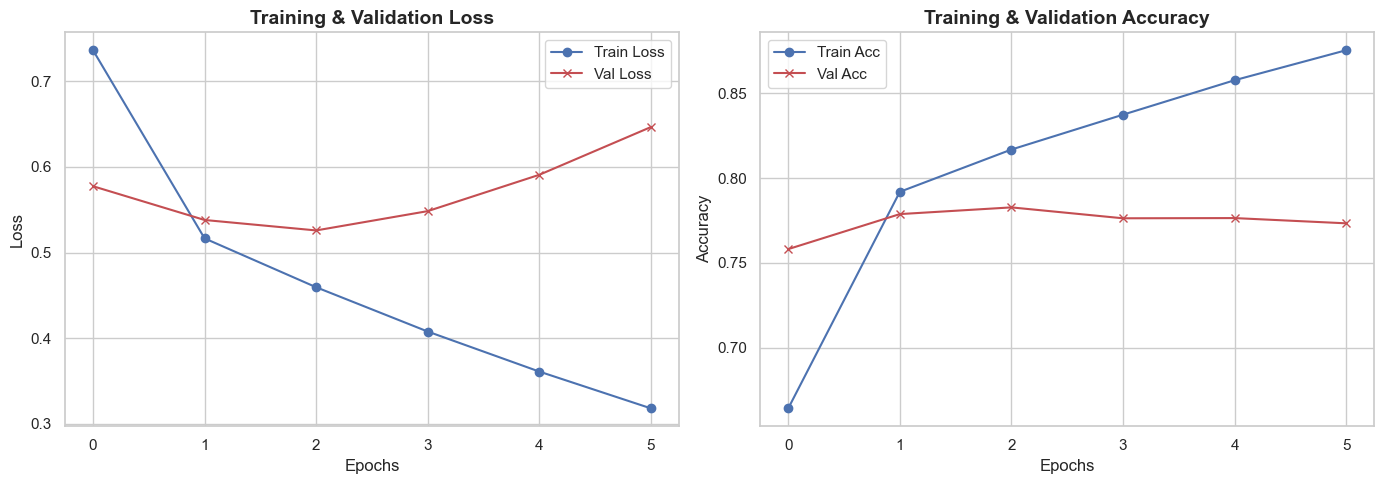

In [17]:
# Plot Loss & Accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
ax1.plot(history.history['loss'], label='Train Loss', color='b', marker='o')
ax1.plot(history.history['val_loss'], label='Val Loss', color='r', marker='x')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy Curve
ax2.plot(history.history['accuracy'], label='Train Acc', color='b', marker='o')
ax2.plot(history.history['val_accuracy'], label='Val Acc', color='r', marker='x')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Evaluasi Model pada Test Set
Melakukan prediksi kelas target pada Test Set (data held-out) kemudian mengevaluasi akurasi, presisi, recall, F1-Score serta menggambar Confusion Matrix.

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step
  EVALUASI MODEL GRU (Test Set)
              precision    recall  f1-score   support

        High       0.91      0.81      0.86      3116
         Low       0.64      0.71      0.67      1831
      Medium       0.76      0.78      0.77      3143

    accuracy                           0.78      8090
   macro avg       0.77      0.77      0.77      8090
weighted avg       0.79      0.78      0.78      8090



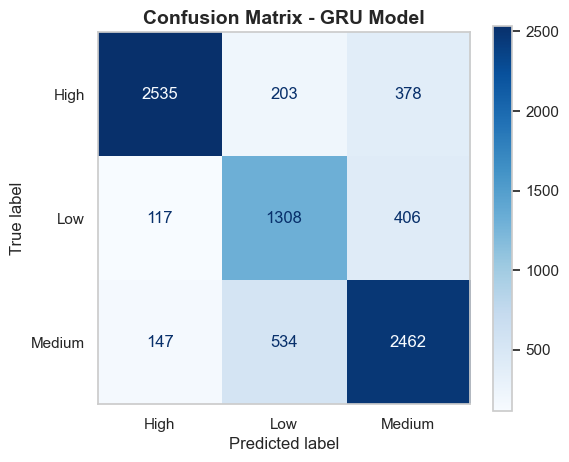

In [18]:
# Prediksi pada data test
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=" * 60)
print("  EVALUASI MODEL GRU (Test Set)")
print("=" * 60)
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

# Visualisasikan Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix - GRU Model', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()